In [1]:
# Celda 1: Importar librerías
import os
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Agregar la carpeta raíz al path para poder importar 'src'
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))

from cargar_datos import cargar_dataset_recontacto
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
from xgboost import XGBClassifier

# Configuración de gráficos
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

print("✅ Librerías cargadas correctamente")


✅ Librerías cargadas correctamente


In [2]:
# Celda 2: Cargar el dataset SUCIO (v0) directamente desde SQL Server
print("🔄 Conectando a SQL Server y cargando el dataset v0 (sin limpiar)...")
df = cargar_dataset_recontacto()

if df is not None:
    print(f"✅ Datos cargados: {df.shape[0]} filas, {df.shape[1]} columnas")
    print(f"⚠️ Este dataset conserva duplicados, etiquetas sin normalizar y valores fuera de rango.")
else:
    print("❌ Error al cargar datos. Revisa tu archivo .env y la conexión a SQL Server.")


🔄 Conectando a SQL Server y cargando el dataset v0 (sin limpiar)...
📊 CARGANDO DATASET v0 DE RECONTACTO (SUCIO)



📏 Dataset v0 (sucio): 98,317 filas × 29 columnas

🎯 Distribución de la variable objetivo (recontacto_7_dias):
recontacto_7_dias
0    57890
1    40427
Name: count, dtype: int64

📈 Tasa de recontacto_7_dias=1: 41.12%
✅ Datos cargados: 98317 filas, 29 columnas
⚠️ Este dataset conserva duplicados, etiquetas sin normalizar y valores fuera de rango.


In [3]:
# Celda 3: Preparar variables para el modelo (VERSIÓN SIMPLE)

# 1. Eliminar columnas que no son predictivas
columnas_a_eliminar = ['id_interaccion', 'fecha_contacto', 'recontacto_7_dias']
X = df.drop(columns=columnas_a_eliminar, errors='ignore').apply(pd.to_numeric)
y = df['recontacto_7_dias'].astype(int)

# 2. Variables categóricas: ya vienen codificadas como binarias desde el SQL
#    (es_canal_*, es_motivo_*, es_cola_*, es_usuario_*, banderas)
columnas_texto = X.select_dtypes(include=['object']).columns
if len(columnas_texto) > 0:
    print(f"⚠️ Columnas de texto detectadas: {list(columnas_texto)}")
    X = pd.get_dummies(X, columns=columnas_texto.tolist(), drop_first=True)
else:
    print("✅ Todas las variables ya son numéricas (no se necesita encoding)")

# 3. Convertir booleanos y rellenar nulos (los datos sucios pueden traer vacíos)
X = X.astype({col: 'int8' for col in X.select_dtypes(include=['bool']).columns})
nulos_antes = int(X.isnull().sum().sum())
X = X.fillna(0)
print(f"✅ Nulos rellenados: {nulos_antes} → 0")
print(f"📊 Features finales: {X.shape[1]}")


✅ Todas las variables ya son numéricas (no se necesita encoding)
✅ Nulos rellenados: 0 → 0
📊 Features finales: 26


In [4]:
# Celda 4: Dividir en entrenamiento (80%) y prueba (20%)
# stratify=y asegura que la proporción de recontactos sea igual en ambos sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print(f"✅ Train: {X_train.shape[0]:,} registros | Test: {X_test.shape[0]:,} registros")


✅ Train: 78,653 registros | Test: 19,664 registros


In [5]:
# Celda 5: Entrenar el modelo
# scale_pos_weight corrige el desbalance de clases (clase 0 / clase 1)
ratio_desbalance = (y_train == 0).sum() / (y_train == 1).sum()

modelo = XGBClassifier(
    n_estimators=600,
    max_depth=5,
    learning_rate=0.05,
    scale_pos_weight=ratio_desbalance,  # Clave para datos desbalanceados
    random_state=42,
    eval_metric='auc'
)

print("🔄 Entrenando modelo XGBoost con el dataset SUCIO...")
modelo.fit(X_train, y_train)
print("✅ Modelo entrenado exitosamente")


🔄 Entrenando modelo XGBoost con el dataset SUCIO...


✅ Modelo entrenado exitosamente


In [6]:
# Celda 6: Evaluar rendimiento en el set de prueba
y_pred = modelo.predict(X_test)
y_pred_proba = modelo.predict_proba(X_test)[:, 1]
auc = roc_auc_score(y_test, y_pred_proba)

print("=" * 60)
print("📊 REPORTE DE CLASIFICACIÓN (DATOS SUCIOS)")
print("=" * 60)
print(classification_report(y_test, y_pred, target_names=['No recontacta (0)', 'Recontacta (1)']))

print(f"🎯 ROC-AUC Score: {auc:.4f}")
print("⚠️ Los duplicados y los valores fuera de rango ensucian el aprendizaje:")
print("   este resultado sirve como línea base para comparar contra el dataset corregido.")


📊 REPORTE DE CLASIFICACIÓN (DATOS SUCIOS)
                   precision    recall  f1-score   support

No recontacta (0)       0.69      0.67      0.68     11578
   Recontacta (1)       0.54      0.56      0.55      8086

         accuracy                           0.62     19664
        macro avg       0.61      0.61      0.61     19664
     weighted avg       0.63      0.62      0.63     19664

🎯 ROC-AUC Score: 0.6644
⚠️ Los duplicados y los valores fuera de rango ensucian el aprendizaje:
   este resultado sirve como línea base para comparar contra el dataset corregido.


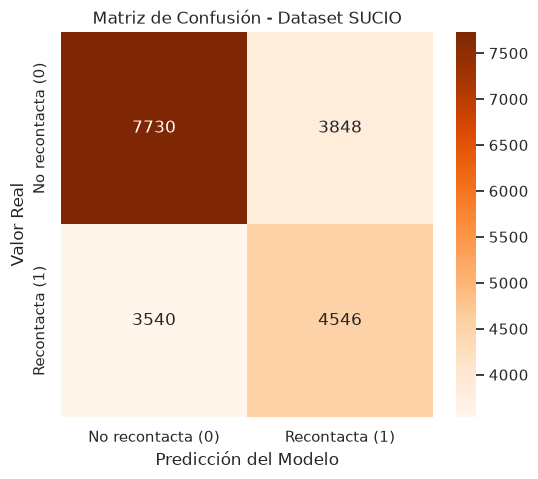

In [7]:
# Celda 7: Gráfico de Matriz de Confusión
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['No recontacta (0)', 'Recontacta (1)'],
            yticklabels=['No recontacta (0)', 'Recontacta (1)'])
plt.title('Matriz de Confusión - Dataset SUCIO')
plt.ylabel('Valor Real')
plt.xlabel('Predicción del Modelo')
plt.show()


/tmp/ipykernel_16/558838489.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importancia', y='Variable', data=df_importancia, palette='viridis')


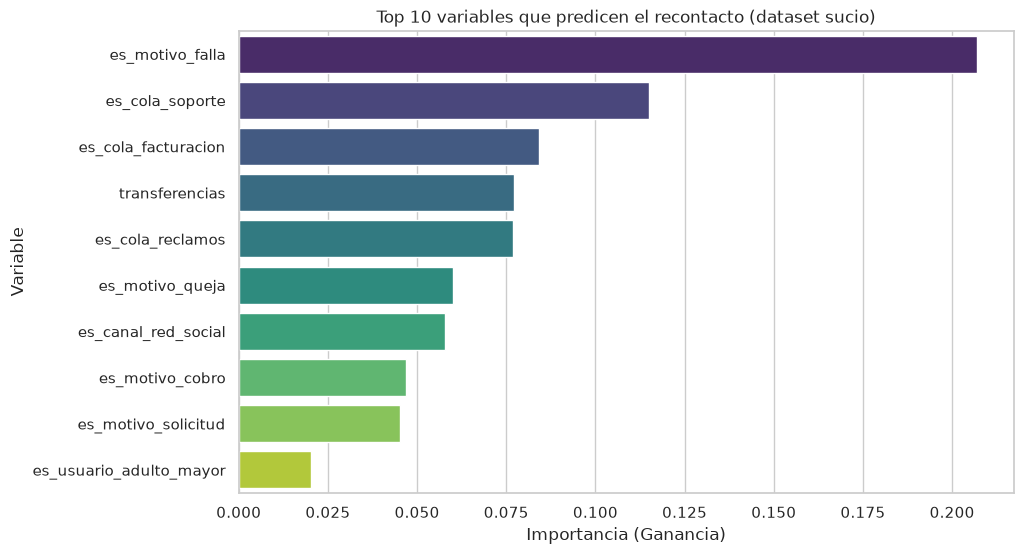

👉 Siguiente paso: el notebook 03_modelado_correcto.ipynb repite el modelo
   con el dataset LIMPIO y compara los resultados.


In [8]:
# Celda 8: ¿Qué variables explican el recontacto?
importancia = modelo.feature_importances_
features = X.columns

df_importancia = pd.DataFrame({'Variable': features, 'Importancia': importancia})
df_importancia = df_importancia.sort_values(by='Importancia', ascending=False).head(10)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importancia', y='Variable', data=df_importancia, palette='viridis')
plt.title('Top 10 variables que predicen el recontacto (dataset sucio)')
plt.xlabel('Importancia (Ganancia)')
plt.ylabel('Variable')
plt.show()

print("👉 Siguiente paso: el notebook 03_modelado_correcto.ipynb repite el modelo")
print("   con el dataset LIMPIO y compara los resultados.")
